# Inventory Management Implementation Notebook

Start-to-finish implementation for inventory analytics on `ecommerce.db` with:
- ABC/XYZ segmentation
- Reorder Point (ROP) and EOQ recommendations
- Inventory-focused exploratory analysis
- Agent-ready recommendation outputs

## 1. Set Up Environment and Imports

In [2]:
import os
import sqlite3
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid')

print('Python modules loaded successfully')
print('pandas', pd.__version__)
print('numpy', np.__version__)

Python modules loaded successfully
pandas 3.0.1
numpy 2.4.3


## 2. Define Configuration and Constants

In [3]:
@dataclass
class InventoryConfig:
    db_path: str = '/home/mikolaj/OptimAIze/ecommerce.db'
    output_dir: str = 'artifacts/inventory_analysis'
    planning_horizon_days: int = 30
    lead_time_days: int = 7
    service_level: float = 0.95
    service_z: float = 1.645  # Approx z-score for 95% cycle service level

    # ABC class-based EOQ assumptions
    order_cost_by_abc: Dict[str, float] = None
    holding_cost_rate_by_abc: Dict[str, float] = None

    def __post_init__(self):
        if self.order_cost_by_abc is None:
            self.order_cost_by_abc = {'A': 70.0, 'B': 50.0
            , 'C': 35.0}
        if self.holding_cost_rate_by_abc is None:
            self.holding_cost_rate_by_abc = {'A': 0.30, 'B': 0.24, 'C': 0.18}

cfg = InventoryConfig()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
cfg

InventoryConfig(db_path='/home/mikolaj/OptimAIze/ecommerce.db', output_dir='artifacts/inventory_analysis', planning_horizon_days=30, lead_time_days=7, service_level=0.95, service_z=1.645, order_cost_by_abc={'A': 70.0, 'B': 50.0, 'C': 35.0}, holding_cost_rate_by_abc={'A': 0.3, 'B': 0.24, 'C': 0.18})

## 3. Load and Validate Input Data

In [4]:
def load_input_tables(config: InventoryConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if not Path(config.db_path).exists():
        raise FileNotFoundError(f'Database not found: {config.db_path}')

    conn = sqlite3.connect(config.db_path)
    try:
        inv = pd.read_sql('SELECT product_id, current_stock, price FROM inventory', conn)
        sales = pd.read_sql('SELECT product_id, date, sales, revenue, price, stock FROM sales_aggregated', conn)
    finally:
        conn.close()

    sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
    for col in ['sales', 'revenue', 'price', 'stock']:
        if col in sales.columns:
            sales[col] = pd.to_numeric(sales[col], errors='coerce')

    inv['current_stock'] = pd.to_numeric(inv['current_stock'], errors='coerce')
    inv['price'] = pd.to_numeric(inv['price'], errors='coerce')

    return inv, sales

inventory_df, sales_df = load_input_tables(cfg)
print('inventory rows:', len(inventory_df))
print('sales rows:', len(sales_df))
display(inventory_df.head(3))
display(sales_df.head(3))

inventory rows: 649
sales rows: 487986


,product_id,current_stock,price
0,P0001,10,8.25
1,P0002,2,283.74
2,P0004,1,4.53


,product_id,date,sales,revenue,price,stock
0,P0001,2017-01-02,6.0,31.79,6.25,195.0
1,P0001,2017-01-03,1.0,5.30,6.25,194.0
2,P0001,2017-01-04,2.0,10.60,6.25,192.0


In [5]:
def validate_schema(inv: pd.DataFrame, sales: pd.DataFrame) -> None:
    required_inv = {'product_id', 'current_stock', 'price'}
    required_sales = {'product_id', 'date', 'sales', 'revenue', 'price', 'stock'}

    missing_inv = required_inv - set(inv.columns)
    missing_sales = required_sales - set(sales.columns)

    assert not missing_inv, f'Missing inventory columns: {missing_inv}'
    assert not missing_sales, f'Missing sales columns: {missing_sales}'
    assert inv['product_id'].notna().all(), 'Null product_id in inventory'
    assert sales['product_id'].notna().all(), 'Null product_id in sales'
    assert sales['date'].notna().any(), 'No parseable sales dates'

def quality_report(inv: pd.DataFrame, sales: pd.DataFrame) -> pd.DataFrame:
    report = {
        'inventory_duplicates': int(inv.duplicated(['product_id']).sum()),
        'sales_duplicates': int(sales.duplicated(['product_id', 'date']).sum()),
        'inventory_missing_price': int(inv['price'].isna().sum()),
        'inventory_missing_stock': int(inv['current_stock'].isna().sum()),
        'sales_missing_date': int(sales['date'].isna().sum()),
        'sales_negative_values': int((sales['sales'].fillna(0) < 0).sum()),
        'sales_date_min': sales['date'].min(),
        'sales_date_max': sales['date'].max(),
        'sku_count_inventory': inv['product_id'].nunique(),
        'sku_count_sales': sales['product_id'].nunique(),
    }
    return pd.DataFrame([report]).T.rename(columns={0: 'value'})

validate_schema(inventory_df, sales_df)
display(quality_report(inventory_df, sales_df))

,value
inventory_duplicates,0
sales_duplicates,0
inventory_missing_price,0
inventory_missing_stock,0
sales_missing_date,0
sales_negative_values,0
sales_date_min,2017-01-02 00:00:00
sales_date_max,2019-12-29 00:00:00
sku_count_inventory,649
sku_count_sales,649


## 4. Implement Core Functions

In [6]:
def build_product_demand_features(sales: pd.DataFrame, horizon_days: int = 30) -> pd.DataFrame:
    """Aggregate per-product demand features for inventory policy decisions."""
    clean = sales.copy()
    clean = clean.dropna(subset=['product_id', 'date'])

    # Use latest horizon for near-term planning and full history for annual value
    last_date = clean['date'].max()
    horizon_start = last_date - pd.Timedelta(days=horizon_days - 1)

    horizon_df = clean[clean['date'] >= horizon_start].copy()
    history_df = clean.copy()

    near_term = horizon_df.groupby('product_id', as_index=False).agg(
        demand_sum_h=('sales', 'sum'),
        demand_mean_daily=('sales', 'mean'),
        demand_std_daily=('sales', 'std'),
        active_days=('sales', 'count')
    )

    annual = history_df.groupby('product_id', as_index=False).agg(
        annual_sales=('sales', 'sum'),
        annual_revenue=('revenue', 'sum')
    )

    features = near_term.merge(annual, on='product_id', how='outer')
    features['demand_std_daily'] = features['demand_std_daily'].fillna(0)
    features['demand_mean_daily'] = features['demand_mean_daily'].fillna(0)
    features['cv'] = np.where(
        features['demand_mean_daily'] > 0,
        features['demand_std_daily'] / features['demand_mean_daily'],
        9.99
    )
    return features

def classify_abc(features: pd.DataFrame) -> pd.DataFrame:
    """Assign ABC classes using cumulative share of annual revenue."""
    df = features.copy()
    df['annual_revenue'] = df['annual_revenue'].fillna(0)
    df = df.sort_values('annual_revenue', ascending=False).reset_index(drop=True)

    total = max(df['annual_revenue'].sum(), 1e-9)
    df['cum_revenue_share'] = df['annual_revenue'].cumsum() / total

    df['abc_class'] = np.select(
        [df['cum_revenue_share'] <= 0.80, df['cum_revenue_share'] <= 0.95],
        ['A', 'B'],
        default='C'
    )
    return df

def classify_xyz(df: pd.DataFrame) -> pd.DataFrame:
    """Assign XYZ classes by coefficient of variation thresholds."""
    out = df.copy()
    out['xyz_class'] = np.select(
        [out['cv'] < 0.5, out['cv'] < 1.0],
        ['X', 'Y'],
        default='Z'
    )
    out['policy_code'] = out['abc_class'] + out['xyz_class']
    return out

def compute_rop_eoq(df: pd.DataFrame, inv: pd.DataFrame, config: InventoryConfig) -> pd.DataFrame:
    """Compute ROP/EOQ/reorder quantity using class-based assumptions."""
    out = df.merge(inv[['product_id', 'current_stock', 'price']], on='product_id', how='left', suffixes=('', '_inv'))

    # Prefer inventory price if present; fallback to sales-derived value
    out['unit_price'] = out['price'].where(out['price'].notna(), 0.0)

    out['daily_demand'] = out['demand_mean_daily'].clip(lower=0)
    out['demand_std_daily'] = out['demand_std_daily'].fillna(0).clip(lower=0)

    out['safety_stock'] = config.service_z * out['demand_std_daily'] * np.sqrt(config.lead_time_days)
    out['rop'] = (out['daily_demand'] * config.lead_time_days) + out['safety_stock']

    out['annual_demand'] = out['daily_demand'] * 365.0
    out['order_cost'] = out['abc_class'].map(config.order_cost_by_abc).fillna(50.0)
    out['holding_cost'] = (
        out['abc_class'].map(config.holding_cost_rate_by_abc).fillna(0.24) *
        out['unit_price'].clip(lower=0.01)
    )

    out['eoq'] = np.sqrt((2.0 * out['annual_demand'] * out['order_cost']) / out['holding_cost'])
    out['eoq'] = out['eoq'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0)

    out['current_stock'] = out['current_stock'].fillna(0).clip(lower=0)
    out['qty_to_rop'] = (out['rop'] - out['current_stock']).clip(lower=0)
    out['reorder_qty'] = np.ceil(np.maximum(out['qty_to_rop'], out['eoq'])).astype(int)

    out['priority'] = np.select(
        [out['current_stock'] < out['rop'], out['policy_code'].isin(['AX', 'AY'])],
        ['REORDER_NOW', 'MONITOR_CLOSELY'],
        default='NORMAL'
    )

    out['stock_cover_days'] = np.where(out['daily_demand'] > 0, out['current_stock'] / out['daily_demand'], np.inf)
    out['overstock_flag'] = out['stock_cover_days'] > 90

    return out

features_df = build_product_demand_features(sales_df, cfg.planning_horizon_days)
classified_df = classify_xyz(classify_abc(features_df))
result_df = compute_rop_eoq(classified_df, inventory_df, cfg)
display(result_df.head(10))

,product_id,demand_sum_h,demand_mean_daily,demand_std_daily,active_days,annual_sales,annual_revenue,cv,cum_revenue_share,abc_class,...,rop,annual_demand,order_cost,holding_cost,eoq,qty_to_rop,reorder_qty,priority,stock_cover_days,overstock_flag
0,P0103,0.0,0.0,0.0,30.0,881634.000,2670199.663,9.99,0.070827,A,...,0.0,0.0,70.0,1.077,0.0,0.0,0,NORMAL,inf,True
1,P0129,0.0,0.0,0.0,30.0,58837.000,1328199.720,9.99,0.106058,A,...,0.0,0.0,70.0,8.697,0.0,0.0,0,NORMAL,inf,True
2,P0500,0.0,0.0,0.0,30.0,161805.000,1300795.320,9.99,0.140561,A,...,0.0,0.0,70.0,2.850,0.0,0.0,0,NORMAL,inf,True
3,P0428,0.0,0.0,0.0,30.0,40303.000,1065853.790,9.99,0.168833,A,...,0.0,0.0,70.0,9.222,0.0,0.0,0,NORMAL,inf,True
4,P0182,0.0,0.0,0.0,30.0,43586.000,823723.090,9.99,0.190682,A,...,0.0,0.0,70.0,6.750,0.0,0.0,0,NORMAL,inf,True
5,P0559,0.0,0.0,0.0,30.0,26468.000,801695.379,9.99,0.211947,A,...,0.0,0.0,70.0,9.885,0.0,0.0,0,NORMAL,inf,True
6,P0316,0.0,0.0,0.0,20.0,12445.277,616486.020,9.99,0.228300,A,...,0.0,0.0,70.0,19.332,0.0,0.0,0,NORMAL,inf,True
7,P0569,0.0,0.0,0.0,30.0,192400.000,615033.040,9.99,0.244613,A,...,0.0,0.0,70.0,1.008,0.0,0.0,0,NORMAL,inf,True
8,P0325,0.0,0.0,0.0,30.0,54407.000,588872.730,9.99,0.260233,A,...,0.0,0.0,70.0,3.549,0.0,0.0,0,NORMAL,inf,True
9,P0261,0.0,0.0,0.0,30.0,146959.000,572555.000,9.99,0.275420,A,...,0.0,0.0,70.0,1.356,0.0,0.0,0,NORMAL,inf,True


In [7]:
# Sample calls to verify behavior
print('Policy distribution:')
display(result_df['policy_code'].value_counts().rename_axis('policy').to_frame('sku_count'))

print('Top reorder candidates:')
display(
    result_df[['product_id', 'policy_code', 'current_stock', 'rop', 'eoq', 'reorder_qty', 'priority']]
    .sort_values(['priority', 'reorder_qty'], ascending=[True, False])
    .head(15)
)

Policy distribution:


,sku_count
policy,
CZ,355
BZ,160
AZ,134


Top reorder candidates:


,product_id,policy_code,current_stock,rop,eoq,reorder_qty,priority
0,P0103,AZ,40,0.0,0.0,0,NORMAL
1,P0129,AZ,1,0.0,0.0,0,NORMAL
2,P0500,AZ,22,0.0,0.0,0,NORMAL
3,P0428,AZ,2,0.0,0.0,0,NORMAL
4,P0182,AZ,5,0.0,0.0,0,NORMAL
5,P0559,AZ,77,0.0,0.0,0,NORMAL
6,P0316,AZ,0,0.0,0.0,0,NORMAL
7,P0569,AZ,17,0.0,0.0,0,NORMAL
8,P0325,AZ,66,0.0,0.0,0,NORMAL
9,P0261,AZ,23,0.0,0.0,0,NORMAL


### Additional Inventory Exploratory Analysis

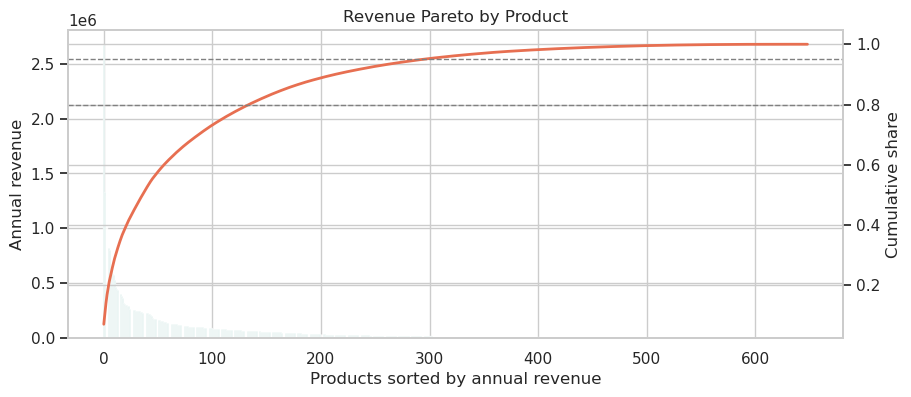

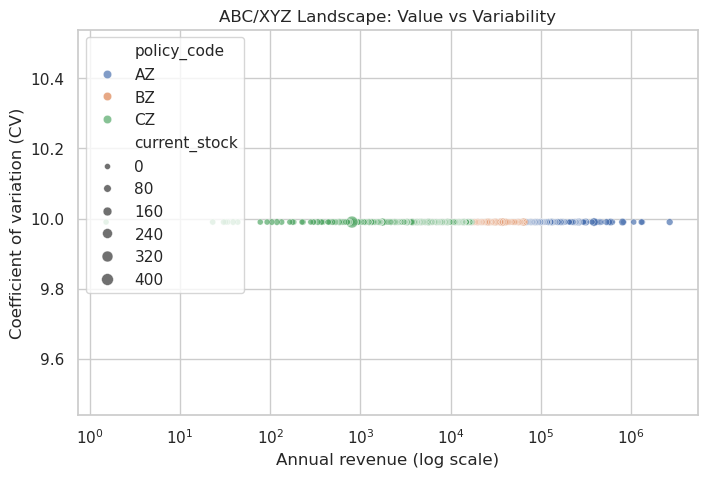

Slow mover SKU count: 649


,product_id,daily_demand,current_stock,stock_cover_days
0,P0103,0.0,40,inf
1,P0129,0.0,1,inf
2,P0500,0.0,22,inf
3,P0428,0.0,2,inf
4,P0182,0.0,5,inf
5,P0559,0.0,77,inf
6,P0316,0.0,0,inf
7,P0569,0.0,17,inf
8,P0325,0.0,66,inf
9,P0261,0.0,23,inf


In [8]:
# Revenue Pareto (ABC intuition)
pareto = (
    result_df[['product_id', 'annual_revenue']]
    .sort_values('annual_revenue', ascending=False)
    .reset_index(drop=True)
)
pareto['cum_share'] = pareto['annual_revenue'].cumsum() / max(pareto['annual_revenue'].sum(), 1e-9)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(pareto.index, pareto['annual_revenue'], color='#2a9d8f', alpha=0.8)
ax1.set_title('Revenue Pareto by Product')
ax1.set_xlabel('Products sorted by annual revenue')
ax1.set_ylabel('Annual revenue')

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['cum_share'], color='#e76f51', linewidth=2)
ax2.axhline(0.80, linestyle='--', color='gray', linewidth=1)
ax2.axhline(0.95, linestyle='--', color='gray', linewidth=1)
ax2.set_ylabel('Cumulative share')
plt.show()

# ABC/XYZ scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=result_df,
    x='annual_revenue',
    y='cv',
    hue='policy_code',
    size='current_stock',
    alpha=0.7
)
plt.xscale('log')
plt.title('ABC/XYZ Landscape: Value vs Variability')
plt.xlabel('Annual revenue (log scale)')
plt.ylabel('Coefficient of variation (CV)')
plt.show()

# Dead stock / slow movers
slow_movers = result_df[result_df['daily_demand'] <= result_df['daily_demand'].median() / 10.0]
print('Slow mover SKU count:', len(slow_movers))
display(slow_movers[['product_id', 'daily_demand', 'current_stock', 'stock_cover_days']].head(20))

## 5. Run Unit Tests in Notebook

In [9]:
import textwrap
import subprocess

test_code = textwrap.dedent('''
import numpy as np
import pandas as pd

def test_abc_split_has_valid_labels():
    df = pd.DataFrame({'product_id':['a','b','c'], 'annual_revenue':[100,50,10], 'demand_mean_daily':[1,1,1], 'demand_std_daily':[0.1,0.2,0.3], 'cv':[0.1,0.2,0.3]})
    out = classify_abc(df)
    assert set(out['abc_class']).issubset({'A','B','C'})

def test_xyz_split_has_valid_labels():
    df = pd.DataFrame({'abc_class':['A','B','C'], 'cv':[0.3,0.8,1.4]})
    out = classify_xyz(df)
    assert list(out['xyz_class']) == ['X','Y','Z']

def test_reorder_qty_non_negative():
    local = result_df.copy()
    assert (local['reorder_qty'] >= 0).all()
''')

test_file = Path(cfg.output_dir) / 'test_inventory_notebook.py'
test_file.write_text(test_code)

cmd = ['pytest', '-q', str(test_file)]
proc = subprocess.run(cmd, capture_output=True, text=True)
print(proc.stdout if proc.stdout else proc.stderr)
print('exit code:', proc.returncode)

FileNotFoundError: [Errno 2] No such file or directory: 'pytest'

## 6. Execute Main Workflow

In [ ]:
def run_inventory_workflow(config: InventoryConfig) -> pd.DataFrame:
    inv, sales = load_input_tables(config)
    validate_schema(inv, sales)

    features = build_product_demand_features(sales, horizon_days=config.planning_horizon_days)
    classified = classify_xyz(classify_abc(features))
    final = compute_rop_eoq(classified, inv, config)

    final['reasoning'] = (
        'Policy=' + final['policy_code'].astype(str) +
        '; stock=' + final['current_stock'].round(1).astype(str) +
        '; rop=' + final['rop'].round(1).astype(str) +
        '; eoq=' + final['eoq'].round(1).astype(str)
    )
    return final

final_df = run_inventory_workflow(cfg)
print('Final workflow rows:', len(final_df))
display(final_df.head(10))

In [ ]:
# Sensitivity analysis: lead-time and variability multipliers
def scenario_view(base: pd.DataFrame, lead_time_days: int, demand_std_mult: float) -> pd.DataFrame:
    tmp = base.copy()
    tmp['safety_stock_scn'] = cfg.service_z * (tmp['demand_std_daily'] * demand_std_mult) * np.sqrt(lead_time_days)
    tmp['rop_scn'] = (tmp['daily_demand'] * lead_time_days) + tmp['safety_stock_scn']
    tmp['qty_to_rop_scn'] = (tmp['rop_scn'] - tmp['current_stock']).clip(lower=0)
    tmp['reorder_qty_scn'] = np.ceil(np.maximum(tmp['qty_to_rop_scn'], tmp['eoq'])).astype(int)
    return tmp[['product_id', 'policy_code', 'reorder_qty_scn']]

base_cols = final_df[['product_id', 'policy_code', 'daily_demand', 'demand_std_daily', 'current_stock', 'eoq']].copy()
scenarios = [
    ('base', cfg.lead_time_days, 1.0),
    ('lt_plus_3', cfg.lead_time_days + 3, 1.0),
    ('vol_plus_20pct', cfg.lead_time_days, 1.2),
]

scenario_tables = []
for name, lt, mult in scenarios:
    t = scenario_view(base_cols, lt, mult).rename(columns={'reorder_qty_scn': f'reorder_qty__{name}'})
    scenario_tables.append(t)

sensitivity_df = scenario_tables[0]
for t in scenario_tables[1:]:
    sensitivity_df = sensitivity_df.merge(t, on=['product_id', 'policy_code'], how='left')

display(sensitivity_df.head(15))

## 7. Inspect Output and Persist Results

In [ ]:
agent_ready_cols = [
    'product_id', 'policy_code', 'abc_class', 'xyz_class',
    'daily_demand', 'demand_std_daily', 'cv',
    'current_stock', 'rop', 'eoq', 'reorder_qty',
    'priority', 'overstock_flag', 'stock_cover_days',
    'annual_revenue', 'reasoning'
]

existing_cols = [c for c in agent_ready_cols if c in final_df.columns]
recommendations_df = final_df[existing_cols].sort_values(['priority', 'reorder_qty'], ascending=[True, False])

output_csv = Path(cfg.output_dir) / 'inventory_recommendations_abc_xyz.csv'
sensitivity_csv = Path(cfg.output_dir) / 'inventory_sensitivity.csv'
summary_csv = Path(cfg.output_dir) / 'inventory_policy_summary.csv'

recommendations_df.to_csv(output_csv, index=False)
sensitivity_df.to_csv(sensitivity_csv, index=False)

policy_summary = recommendations_df.groupby('policy_code', as_index=False).agg(
    sku_count=('product_id', 'count'),
    avg_reorder_qty=('reorder_qty', 'mean')
)
policy_summary.to_csv(summary_csv, index=False)

display(policy_summary.sort_values('sku_count', ascending=False))
print('Saved:', output_csv)
print('Saved:', sensitivity_csv)
print('Saved:', summary_csv)